In [ ]:
import pandas as pd
import sklearn
import numpy as np
import kagglehub
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Download latest version

path1 = kagglehub.dataset_download("uciml/iris")
path2 = kagglehub.dataset_download("uciml/glass")
path3 = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification")

print("Path to dataset files:", path1)
print("Path to dataset files:", path2)
print("Path to dataset files:", path3)

In [ ]:
def accuracy(tp,tn,fp,fn):
  return (tp+tn)/(tp+tn+fp+fn)

def sensitivity (tp, fn):
  return tp/(tp+fn)

def specifity(tn,fp):
  return tn/(tn+fp)

def precision (tp,fp):
  return tp/(tp+fp)

def f1 (pr,re):
  return 2*pr*re/(pr+re)

In [ ]:

from sklearn.preprocessing import LabelEncoder

class Svm:
  def __init__(self,kernel, C=1, D2=-1, D1=3):
        self.C = C
        self.eps = 0
        self.learning_rate = 0.001
        self.max_iter = 10
        self.D2=D2
        self.D1=D1
        self.kernel=kernel

  def linear( self, X, Y):
    return X @ Y.T

  def polynominal(self,X, Y):
    gamma=1.0 / (X.shape[1] * X.var()) if X.shape[1] > 0 else 1.0
    return (gamma * X @ Y.T +1)**self.D1

  def rbf (self,X, Y):
    gamma=1.0 / (X.shape[1] * X.var()) if X.shape[1] > 0 else 1.0
    x_n=np.sum(X**2,axis=1)
    y_n=np.sum(Y**2,axis=1)
    K=x_n[:, np.newaxis] +y_n[np.newaxis,:]-2 * X @ Y.T
    return np.exp(-gamma * K)

  def sigmoid(self,X,Y):
    gamma=1.0 / (X.shape[1] * X.var()) if X.shape[1] > 0 else 1.0
    return np.tanh(gamma * X @ Y.T + self.D2 )

  def kernel_func(self, X, Y):
    if self.kernel == 'linear':
            return self.linear(X, Y)
    elif self.kernel == 'poly':
            return self.polynominal(X, Y)
    elif self.kernel == 'rbf':
            return self.rbf(X, Y)
    elif self.kernel == 'sigmoid':
            return self.sigmoid(X, Y)

  def find_weight(self, x, y):
    n_samples, n_features = x.shape
    bias = 0
    alpha = np.zeros(n_samples)
    K = self.kernel_func(x, x)

    for iteration in range(self.max_iter):
        for i in range(n_samples):
            y_pred = np.sum(alpha * y * K[i, :]) + bias
            margin = y[i] * y_pred

            if margin < 1:
                alpha[i] += self.learning_rate * (1 - margin)
            else:
                alpha[i] -= self.learning_rate * (margin - 1)

            bias += self.learning_rate * y[i] * (1 - margin)

        alpha = np.clip(alpha, 0, self.C)

        if iteration > 100 and np.max(np.abs(alpha - prev_alpha)) < 1e-6:
            break
        prev_alpha = alpha.copy()

    return bias, alpha

  def _count_support_vectors(self):
    total = 0
    for i in range(len(self.bias)):
        support_mask = self.alphas[i] > 6e-3
        total += np.sum(support_mask)
    return total // len(self.bias)

  def fit(self, x, y):
        classes=np.unique(y)
        n_classes=len(classes)
        n_samples, n_feature = x.shape

        self.bias = np.zeros(n_classes)
        self.alphas = np.zeros((n_classes, n_samples))
        self.support_vectors_ = x
        self.support_labels_ = y

        np.random.seed(42)

        self.label_encoder = LabelEncoder()
        y_encoded = self.label_encoder.fit_transform(y)
        for i, cls in enumerate(classes):
            y_binary = np.where(y == cls, 1, -1)
            self.bias[i], self.alphas[i] = self.find_weight(x, y_binary)
        self.n_support_vectors_ = self._count_support_vectors()


  def predict(self, x):
        K_test = self.kernel_func(x, self.support_vectors_)

        decisions = np.zeros((x.shape[0], len(self.bias)))

        for i in range(len(self.bias)):
            binary_labels = np.where(self.support_labels_ == self.label_encoder.classes_[i], 1, -1)

            for j in range(x.shape[0]):
                decisions[j, i] = np.sum(self.alphas[i] * binary_labels * K_test[j, :]) + self.bias[i]

        return self.label_encoder.inverse_transform(np.argmax(decisions, axis=1))



In [ ]:
#Iris
# df = pd.read_csv('/kaggle/input/iris/Iris.csv', sep = ',', index_col=False)
# df =df.drop("Id", axis=1)
# #df = df[df['Species'] != 'Iris-virginica']
# X=df.drop('Species',axis=1).values
# mapping = {name: i for i, name in enumerate(df["Species"].unique(), start=1)}
# df["Species"]=df["Species"].map(mapping)
# Y=df['Species']
# class_count= df["Species"].nunique()

# Glass
# df = pd.read_csv('/kaggle/input/glass/glass.csv', sep = ',', index_col=False)
# df = df[~df['Type'].isin([3,4,5,6,7])]
# X=df.drop('Type',axis=1).values
# Y=df['Type']
# X=sklearn.preprocessing.normalize(X,norm='l2')
# class_count= df["Type"].nunique()

# Derma
df = pd.read_csv('/kaggle/input/dermatology-dataset-classification/dermatology_database_1.csv', sep = ',', index_col=False)
df=df.drop('age',axis=1)
X=df.drop('class',axis=1).values
Y=df['class']
class_count= df["class"].nunique()


x_train,x_test,y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=random.randint(1,100)
)

print(f"y_test = {list(y_test)}")
lsvm=Svm('linear')
lsvm.fit(x_train,y_train)
psvm=Svm('poly')
psvm.fit(x_train,y_train)
rsvm=Svm('rbf')
rsvm.fit(x_train,y_train)
ssvm=Svm('sigmoid')
ssvm.fit(x_train,y_train)

def init_metrics_per_class(n_classes=class_count):
    metrics = {}
    for class_idx in range(1,n_classes+1):
        metrics[class_idx] = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0}
    return metrics

lmetrics = init_metrics_per_class()
pmetrics = init_metrics_per_class()
rmetrics = init_metrics_per_class()
smetrics = init_metrics_per_class()

vse = ((lsvm, lmetrics, 'Linear'), (psvm, pmetrics, 'Polynomial'),
       (rsvm, rmetrics, 'RBF'), (ssvm, smetrics, 'Sigmoid'))

for model, metrics, name in vse:
    y_pred = model.predict(x_test)
    print(f"{name} predicted: {y_pred}")

    for class_idx in range(1,class_count+1):
        for true_label, pred_label in zip(y_test, y_pred):
            true_pos = (true_label == class_idx) and (pred_label == class_idx)
            true_neg = (true_label != class_idx) and (pred_label != class_idx)
            false_pos = (true_label != class_idx) and (pred_label == class_idx)
            false_neg = (true_label == class_idx) and (pred_label != class_idx)

            if true_pos:
                metrics[class_idx]['tp'] += 1
            if true_neg:
                metrics[class_idx]['tn'] += 1
            if false_pos:
                metrics[class_idx]['fp'] += 1
            if false_neg:
                metrics[class_idx]['fn'] += 1
    print(f"{name} SVM - Опорных векторов: {model.n_support_vectors_}")


def calculate_average_metrics(metrics_dict):
    avg_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0}
    n_classes = len(metrics_dict)

    for class_metrics in metrics_dict.values():
        for key in avg_metrics:
            avg_metrics[key] += class_metrics[key]

    for key in avg_metrics:
        avg_metrics[key] /= n_classes

    return avg_metrics

lmetrics_avg = calculate_average_metrics(lmetrics)
pmetrics_avg = calculate_average_metrics(pmetrics)
rmetrics_avg = calculate_average_metrics(rmetrics)
smetrics_avg = calculate_average_metrics(smetrics)


for name, metrics1 in [("Linear", lmetrics_avg), ("Polynomial", pmetrics_avg),
                     ("RBF", rmetrics_avg), ("Sigmoid", smetrics_avg)]:

    print()
    print(f"{name} SVM:")
    print(f"  tp { metrics1['tp']:.2f}, fp { metrics1['fp']:.2f}, tn  {metrics1['tn']:.2f}, fn { metrics1['fn']:.2f}")

    acc = accuracy(metrics1['tp'], metrics1['tn'], metrics1['fp'], metrics1['fn'])
    prec = precision(metrics1['tp'], metrics1['fp'])
    rec = sensitivity(metrics1['tp'], metrics1['fn'])
    f1_score = f1(prec, rec)
    spec = specifity(metrics1['tn'], metrics1['fp'])

    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1_score:.4f}")
    print(f"  Specificity: {spec:.4f}")



y_test = [1, 2, 5, 4, 6, 3, 1, 3, 3, 3, 3, 1, 2, 4, 5, 1, 3, 4, 2, 5, 3, 3, 1, 3, 1, 1, 1, 1, 1, 3, 1, 1, 6, 5, 6, 5, 2, 1, 1, 5, 2, 3, 3, 4, 1, 6, 2, 3, 6, 5, 1, 3, 5, 3, 2, 5, 2, 6, 5, 5, 1, 4, 2, 4, 5, 4, 5, 2, 3, 1, 1, 4, 4, 5]
Linear predicted: [1 2 5 4 1 3 1 3 3 3 3 1 1 1 5 1 3 4 2 5 3 3 1 3 1 1 1 1 1 3 1 1 6 5 6 5 1
 1 1 5 1 3 3 4 1 1 2 3 6 5 1 3 1 3 1 5 2 1 5 1 1 1 1 1 5 4 1 2 3 1 1 1 4 1]
Linear SVM - Опорных векторов: 27
Polynomial predicted: [1 2 5 4 1 3 1 3 3 3 3 1 2 4 5 1 3 4 2 5 3 3 1 3 1 1 1 1 1 3 1 1 6 5 6 5 2
 1 1 5 2 3 3 4 1 6 2 3 6 5 1 3 5 3 2 5 2 6 5 5 1 4 2 4 5 2 5 2 3 1 1 4 4 5]
Polynomial SVM - Опорных векторов: 41
RBF predicted: [1 2 1 2 1 3 1 3 3 3 3 1 1 1 5 1 3 2 2 1 3 3 1 1 1 1 1 1 1 3 1 1 1 1 1 1 2
 1 1 1 2 3 3 2 1 1 2 3 1 1 1 3 1 3 1 1 2 1 5 1 1 1 2 2 5 2 1 2 3 1 1 2 2 1]
RBF SVM - Опорных векторов: 74
Sigmoid predicted: [1 2 1 2 1 3 1 3 3 3 3 1 1 1 1 1 3 2 2 1 3 3 1 3 1 1 1 1 1 3 1 1 1 1 1 1 2
 1 1 1 1 3 3 2 1 1 2 3 1 1 1 3 1 3 1 1 2 1 5 1 1 1 1 1 1 2 1 2 

In [ ]:
C_values = np.logspace(-4, -1, 5)
D_values = np.linspace(1, 5, 5)

results = np.zeros((len(D_values), len(C_values)))

for i, y in enumerate(D_values):
    for j, x in enumerate(C_values):
        psvmN=Svm('poly', C=x, D1=y)
        psvmN.fit(x_train,y_train)
        pmetrics = init_metrics_per_class()
        y_pred = psvmN.predict(x_test)

        for class_idx in range(1,class_count+1):
          for true_label, pred_label in zip(y_test, y_pred):
            true_pos = (true_label == class_idx) and (pred_label == class_idx)
            true_neg = (true_label != class_idx) and (pred_label != class_idx)
            false_pos = (true_label != class_idx) and (pred_label == class_idx)
            false_neg = (true_label == class_idx) and (pred_label != class_idx)

            if true_pos:
                pmetrics[class_idx]['tp'] += 1
            if true_neg:
                pmetrics[class_idx]['tn'] += 1
            if false_pos:
                pmetrics[class_idx]['fp'] += 1
            if false_neg:
                pmetrics[class_idx]['fn'] += 1

        pmetrics_avg = calculate_average_metrics(pmetrics)
        results[i, j] = accuracy(pmetrics_avg['tp'], pmetrics_avg['tn'], pmetrics_avg['fp'], pmetrics_avg['fn'])


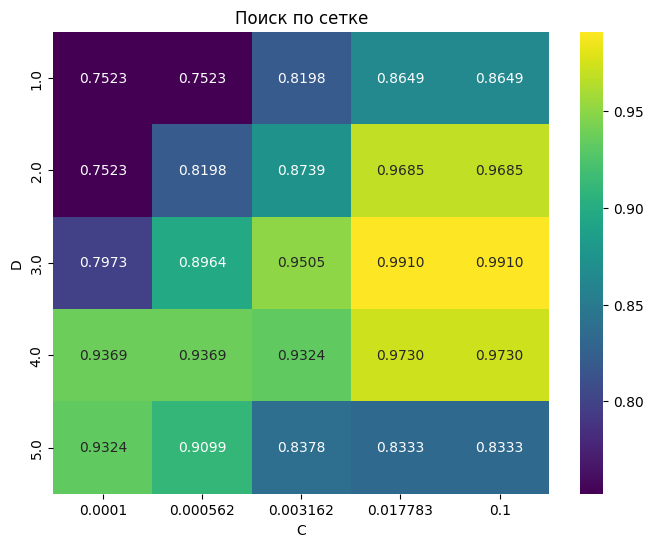

Наибольшая точность = 0.9910, при C=0.0178, D=3.0000


In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(results, annot=True, fmt=".4f", cmap="viridis",
            xticklabels=np.round(C_values, 6),
            yticklabels=np.round(D_values, 2))
plt.xlabel("С")
plt.ylabel("D")
plt.title("Поиск по сетке")
plt.show()
i, j = np.unravel_index(np.argmax(results), results.shape)
print(f"Наибольшая точность = {results[i, j]:.4f}, при C={C_values[j]:.4f}, D={D_values[i]:.4f}")